# Разведочный анализ данных сервиса «Т-Банк Путешествия»

**Автор:** Анастасия Король

## Цель исследования

Провести разведочный анализ данных о пользователях и заказах сервиса
«Т-Банк Путешествия», выявить особенности клиентского поведения,
сформулировать продуктовые гипотезы и выбрать наиболее перспективную.


In [ ]:
from pathlib import Path

file_path = Path('../data/dano_dataset_travel.csv')

if not file_path.exists():
    raise FileNotFoundError(
        "Dataset not found. Download it from "
        "https://dano.hse.ru/data2024 "
        "and place it in the data/ directory."
    )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [133]:
import pandas as pd

### Описание источника

Датасет содержит информацию о заказах авиабилетов и отелей в сервисе
«Т-Банк Путешествия», применении промокодов и дополнительного кешбэка,
характеристиках клиентов, а также о потенциальных клиентах, которые
на момент сбора данных ещё не совершили бронирование.

Для интерпретации полей использован официальный словарь данных.
При этом трактовки отдельных полей дополнительно проверяются на фактических
значениях, поскольку столбец даты отмены полностью не заполнен, а расшифровка
кодов статуса заказа в документации отсутствует.

In [93]:
data = pd.read_csv(
    file_path,
    sep=';',
    decimal=',',
    encoding='utf-8',
    low_memory=False #чтобы Pandas внимательно проверял тип каждого столбца
)

print('Датасет успешно загружен')
print(f'Количество строк: {data.shape[0]:,}')
print(f'Количество столбцов: {data.shape[1]}')

Датасет успешно загружен
Количество строк: 835,938
Количество столбцов: 56


In [94]:
display(data.head()) #смотрим на данные

,order_online_payment_flg,account_rk,client_rk,order_rk,loyalty_program_type_nm,bundle_nm,order_type_cd,order_status_cd,party_first_order_dt,party_first_order_type_dt,...,last_used_product_cd,first_used_product_cd,mobile_phone_operator_nm,marital_status_cd,education_level_cd,birth_place,gender_cd,last_sms_dt,last_email_send_dt,last_session_dttm
0,1.0,209c833731e84d21b5b7e673e0fb848749b9e7d29cda64...,f4959ffb27271192727050953ecb27a8a8a38af413f3d8...,fe1c6ce13774d102c655df4c01d54c34d495ef3d4c7e63...,Bravo,Pro,AIR,SUC,2019-12-12,2019-12-12,...,MPL,MPL,Тинькофф Мобайл,NaN,NaN,ГОР ЯРОСЛАВЛЬ,M,2024-07-02,NaN,2024-11-06 19:42:52.000000
1,1.0,2bbcde706bead3731f2dc8dfbeefb4e12b42ac63e3d8ba...,7025587bc277176246bc44dff396036552a41d5a92d6aa...,98cb83b7748cdf77e43a50f56335a376b51fb767893303...,Tinkoff Black Premium,Premium,HOT,SUC,2019-11-21,2023-09-20,...,INV,IBN,TELE2,MAR,GRD,Р П ВЛАДИМИР 30,M,2024-06-26,NaN,2024-11-06 23:36:38.000000
2,1.0,a82919af3a5a1869f9becdcffa5c7d303d105797ce45b8...,0368b36ccd204d631305233a1f952bc5fb0e3fd9f690fa...,1bfb05606a8b16d48121b9f128889cc1d198c87d223a1b...,Tinkoff Black Premium,Premium,AIR,SUC,2023-01-01,2023-01-01,...,MPL,MPL,Скартел,UNM,GRD,ГОРОД АБАКАН РЕСПУБЛИКИ ХАКАСИЯ,M,2024-07-15,NaN,2024-11-06 11:30:31.000000
3,1.0,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,1346344779d7bd788d03ec2ad1908daf71c6358aca47f1...,011a98649e7a2be3027ec27c1f0b0cb5dd5d82dda2f482...,NaN,Premium,HOT,NaN,2023-12-18,2023-12-18,...,MPL,MPL,Билайн,NaN,NaN,Г СТОКГОЛЬМ ШВЕЦИЯ,M,2024-06-25,NaN,2024-11-06 15:33:18.000000
4,1.0,3133e7ae6698dcda9754d6a8b449782320260ff1259547...,1a2a4351a96099f9e49bbe2fc7236d41ac63b444176058...,b5e7909d8d7b902e4cdf268ebcbef6820c10b0ed75614b...,Tinkoff Black Premium,Premium,AIR,SUC,2019-02-18,2019-02-18,...,MPL,MPL,МегаФон,MAR,GRD,ГОР. МОСКВА,M,2024-07-15,2012-04-19,2024-11-06 23:42:28.000000


In [95]:
data.info() #смотрим структуру

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835938 entries, 0 to 835937
Data columns (total 56 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   order_online_payment_flg     786885 non-null  float64
 1   account_rk                   835938 non-null  object 
 2   client_rk                    835938 non-null  object 
 3   order_rk                     835938 non-null  object 
 4   loyalty_program_type_nm      754957 non-null  object 
 5   bundle_nm                    588049 non-null  object 
 6   order_type_cd                786885 non-null  object 
 7   order_status_cd              779514 non-null  object 
 8   party_first_order_dt         786885 non-null  object 
 9   party_first_order_type_dt    786767 non-null  object 
 10  free_cancel_booking_dttm     75600 non-null   object 
 11  created_dttm                 786885 non-null  object 
 12  cancel_dttm                  0 non-null       float64
 13 

In [96]:
print('Количество столбцов:', len(data.columns))

print('\nНазвания столбцов:')
for number, column in enumerate(data.columns, start=1): #нумеруем столбцы с единицы, чтобы список было легче читать
    print(f'{number}. {column}')

Количество столбцов: 56

Названия столбцов:
1. order_online_payment_flg
2. account_rk
3. client_rk
4. order_rk
5. loyalty_program_type_nm
6. bundle_nm
7. order_type_cd
8. order_status_cd
9. party_first_order_dt
10. party_first_order_type_dt
11. free_cancel_booking_dttm
12. created_dttm
13. cancel_dttm
14. book_start_dttm
15. local_book_start_dttm
16. book_end_dttm
17. hotel_country
18. hotel_city
19. avia_dep_city
20. avia_arr_city
21. promo_code_discount_amt
22. loyalty_accrual_rub_amt
23. nominal_price_eur_amt
24. nominal_price_rub_amt
25. order_item_cnt
26. month_beginning_balance_rub
27. monthly_income_amt
28. suppress_email_flg
29. suppress_call_flg
30. bounce_cd
31. last_sms_success_flg
32. call_contact_6m_flg
33. call_contact_3m_flg
34. call_contact_1m_flg
35. good_email_address_flg
36. bad_email_address_flg
37. email_valid_flg
38. children_cnt
39. age
40. age_type_cd
41. parent_meeting_region_nm
42. delivery_region_category_cd
43. lvn_city_nm
44. lvn_state_nm
45. time_zone_delt

## 1. Знакомство с данными и проверка гранулярности

Датасет содержит информацию о заказах сервиса «Т-Банк Путешествия»,
а также характеристики пользователей, которые потенциально могли совершить
заказ. Перед проведением анализа необходимо определить, чему соответствует
одна строка таблицы, и проверить уникальность ключевых идентификаторов.

In [97]:
#Проверяем гранулярность
id_summary = pd.DataFrame({
    'Количество уникальных значений': [
        data['account_rk'].nunique(),
        data['client_rk'].nunique(),
        data['order_rk'].nunique()
    ],
    'Количество пропусков': [
        data['account_rk'].isna().sum(),
        data['client_rk'].isna().sum(),
        data['order_rk'].isna().sum()
    ]
}, index=['account_rk', 'client_rk', 'order_rk'])

display(id_summary)

print('Количество строк:', len(data))
print('Полностью повторяющихся строк:', data.duplicated().sum())
print('Повторяющихся order_rk:', data['order_rk'].duplicated().sum())

,Количество уникальных значений,Количество пропусков
account_rk,133885,0
client_rk,148364,0
order_rk,786886,0


Количество строк: 835938
Полностью повторяющихся строк: 0
Повторяющихся order_rk: 49052


In [98]:
#Исследуем типы и статусы заказов
print('Распределение по типам заказа:')
display(
    data['order_type_cd']
    .value_counts(dropna=False)
    .rename_axis('Тип заказа')
    .reset_index(name='Количество строк')
)

print('Распределение по статусам заказа:')
display(
    data['order_status_cd']
    .value_counts(dropna=False)
    .rename_axis('Статус заказа')
    .reset_index(name='Количество строк')
)

Распределение по типам заказа:


,Тип заказа,Количество строк
0,AIR,615337
1,HOT,171548
2,NaN,49053


Распределение по статусам заказа:


,Статус заказа,Количество строк
0,SUC,759950
1,NaN,56424
2,PRC,18467
3,ERR,650
4,NSH,304
5,CNC,84
6,REJ,58
7,BRN,1


In [99]:
#Проверяем строки без типа заказа
no_order_mask = data['order_type_cd'].isna()

print('Строк без типа заказа:', no_order_mask.sum())
print(
    'Доля строк без типа заказа:',
    f'{no_order_mask.mean():.2%}'
)

columns_to_check = [
    'client_rk',
    'order_rk',
    'order_type_cd',
    'order_status_cd',
    'created_dttm',
    'book_start_dttm',
    'nominal_price_rub_amt',
    'promo_code_discount_amt',
    'loyalty_accrual_rub_amt',
    'age',
    'gender_cd'
]

display(data.loc[no_order_mask, columns_to_check].head(10))

Строк без типа заказа: 49053
Доля строк без типа заказа: 5.87%


,client_rk,order_rk,order_type_cd,order_status_cd,created_dttm,book_start_dttm,nominal_price_rub_amt,promo_code_discount_amt,loyalty_accrual_rub_amt,age,gender_cd
59,a1730b3f4f3f05e42cd464884cd5f09555ded9dc165942...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.0,F
75,2722bf1a77625145d499de36b86c1fba94d64a848e14e7...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.0,M
114,4a6203572f9ebd2e0d9b277922d36307f9e24c4834ec32...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.0,M
124,a02d4059f939a0696a99d3561ac00bd971d40c545306fa...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.0,M
170,3155b0de93154eaa07483c1f3579d8605c0ac38636506c...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.0,F
193,95f030eb69e32fb20eba153f1b57e20f32e652cd9f2aae...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.0,F
210,f46c6365196c72fe9b1ef8db250250a47907271a2255b2...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.0,F
225,c453713ca85b1179873c071d9f43687cb532484d41d26a...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.0,F
226,ee32cce183b9506a34d92b549492a612145f5d0124b952...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.0,M
233,1785872a40bb7e1c5fa26a81b410ed3babdb6d6d2b3510...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,F


In [100]:
#Проверяем, какие поля отсутствуют одновременно
transaction_columns = [
    'order_type_cd',
    'order_status_cd',
    'created_dttm',
    'book_start_dttm',
    'nominal_price_rub_amt'
]

missing_pattern = (
    data.loc[no_order_mask, transaction_columns]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)

missing_pattern.columns = ['Поле', 'Доля пропусков, %']

display(missing_pattern)

,Поле,"Доля пропусков, %"
0,order_type_cd,100.0
1,order_status_cd,100.0
2,created_dttm,100.0
3,book_start_dttm,100.0
4,nominal_price_rub_amt,100.0


### Промежуточный вывод

Датасет содержит 835 938 наблюдений, из которых 786 885 относятся
к заказам, а 49 053 — к потенциальным клиентам без заказа.

Среди заказов 78,2% приходится на авиабилеты и 21,8% — на отели.
У потенциальных клиентов полностью отсутствуют транзакционные характеристики:
тип и статус заказа, дата создания, дата начала поездки и стоимость.
При этом клиентские характеристики заполнены.

Таким образом, в датасете объединены две сущности: заказы и потенциальные
клиенты. Для дальнейшего анализа их необходимо разделять. Идентификатор
`order_rk` у потенциальных клиентов является технической заглушкой и не может
использоваться для подсчёта их количества.


In [101]:
#Разделяем заказы и потенциальных клиентов
orders = data[data['order_type_cd'].notna()].copy()
prospects = data[data['order_type_cd'].isna()].copy()

print(f'Количество строк с заказами: {len(orders):,}')
print(f'Количество потенциальных клиентов: {len(prospects):,}')
print(f'Суммарное количество строк: {len(orders) + len(prospects):,}')

Количество строк с заказами: 786,885
Количество потенциальных клиентов: 49,053
Суммарное количество строк: 835,938


In [102]:
#Проверяем гранулярность отдельно
granularity = pd.DataFrame({
    'Показатель': [
        'Строки',
        'Уникальные клиенты',
        'Уникальные счета',
        'Уникальные order_rk',
        'Полные дубликаты'
    ],
    'Заказы': [
        len(orders),
        orders['client_rk'].nunique(),
        orders['account_rk'].nunique(),
        orders['order_rk'].nunique(),
        orders.duplicated().sum()
    ],
    'Потенциальные клиенты': [
        len(prospects),
        prospects['client_rk'].nunique(),
        prospects['account_rk'].nunique(),
        prospects['order_rk'].nunique(),
        prospects.duplicated().sum()
    ]
})

display(granularity)

,Показатель,Заказы,Потенциальные клиенты
0,Строки,786885,49053
1,Уникальные клиенты,99311,49053
2,Уникальные счета,133885,1
3,Уникальные order_rk,786885,1
4,Полные дубликаты,0,0


In [103]:
print(
    'Повторяющихся order_rk среди заказов:',
    orders['order_rk'].duplicated().sum()
)

Повторяющихся order_rk среди заказов: 0


In [104]:
#Проверяем статусы отдельно для авиа и отелей
status_by_type = pd.crosstab(
    index=orders['order_type_cd'],
    columns=orders['order_status_cd'].fillna('Нет статуса'),
    margins=True
)

display(status_by_type)

order_status_cd,BRN,CNC,ERR,NSH,PRC,REJ,SUC,Нет статуса,All
order_type_cd,,,,,,,,,
AIR,1,63,650,0,18467,0,596156,0,615337
HOT,0,21,0,304,0,58,163794,7371,171548
All,1,84,650,304,18467,58,759950,7371,786885


In [105]:
#Рассчитываем доли статусов
status_share_by_type = pd.crosstab(
    index=orders['order_type_cd'],
    columns=orders['order_status_cd'].fillna('Нет статуса'),
    normalize='index'
).mul(100).round(2)

display(status_share_by_type)

order_status_cd,BRN,CNC,ERR,NSH,PRC,REJ,SUC,Нет статуса
order_type_cd,,,,,,,,
AIR,0.0,0.01,0.11,0.00,3.0,0.00,96.88,0.0
HOT,0.0,0.01,0.00,0.18,0.0,0.03,95.48,4.3


In [106]:
#Преобразуем дату создания заказа
orders['created_dttm'] = pd.to_datetime(
    orders['created_dttm'],
    errors='coerce'
)

print('Самая ранняя дата:', orders['created_dttm'].min())
print('Самая поздняя дата:', orders['created_dttm'].max())
print('Не удалось преобразовать:', orders['created_dttm'].isna().sum())

Самая ранняя дата: 2024-01-01 00:02:34.084050
Самая поздняя дата: 2024-11-07 00:44:48.439000
Не удалось преобразовать: 0


In [107]:
#Считаем заказы по месяцам
orders['created_month'] = (
    orders['created_dttm']
    .dt.to_period('M') #оставляет от даты только год и месяц
    .astype(str)
)

monthly_orders = (
    orders
    .groupby(['created_month', 'order_type_cd']) #группирует строки по месяцу и типу продукта
    .size() #считает количество строк-заказов
    .reset_index(name='orders_count') #превращает результат обратно в удобную таблицу
)

display(monthly_orders)

,created_month,order_type_cd,orders_count
0,2024-01,AIR,54310
1,2024-01,HOT,11622
2,2024-02,AIR,53032
3,2024-02,HOT,12865
4,2024-03,AIR,55924
5,2024-03,HOT,16656
6,2024-04,AIR,57958
7,2024-04,HOT,17648
8,2024-05,AIR,59895
9,2024-05,HOT,17659


Видна динамика:
*   авиазаказы росли до июля, затем постепенно снижались;
*   отели росли почти весь период, максимум — в сентябре;
*   ноябрь резко ниже только потому, что содержит данные за 7 дней.



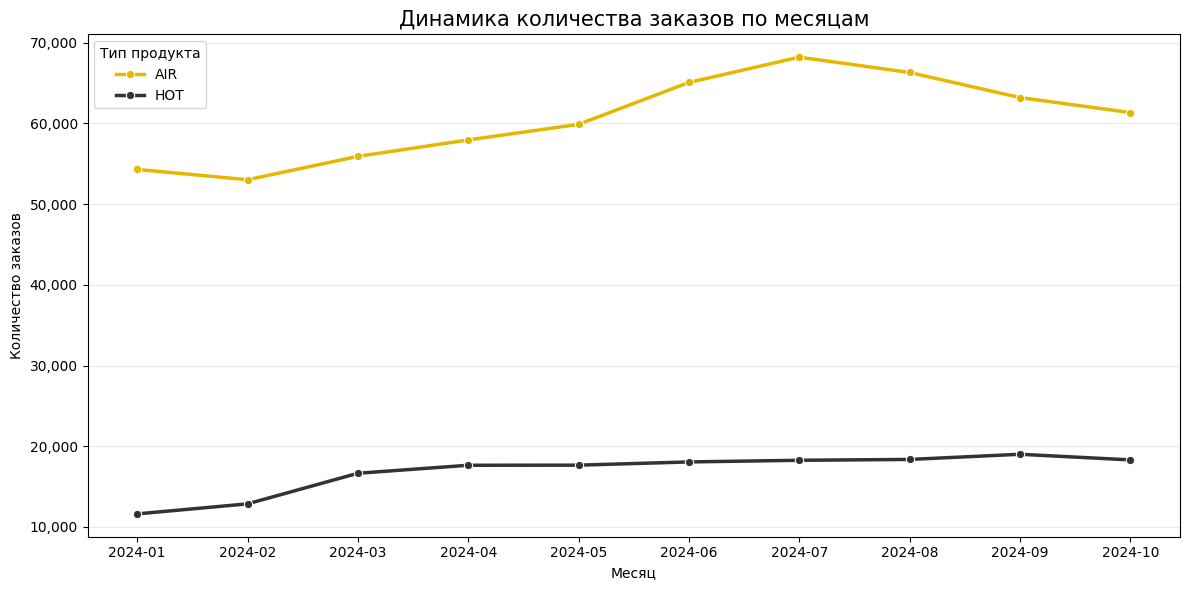

In [ ]:
#Строим первый график; Исключим неполный ноябрь, чтобы он не создавал ложное падение
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

monthly_complete = monthly_orders[
    monthly_orders['created_month'] != '2024-11'
]

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=monthly_complete,
    x='created_month',
    y='orders_count',
    hue='order_type_cd',
    marker='o',
    linewidth=2.5,
    palette={
        'AIR': '#E5B800',
        'HOT': '#333333'
    }
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f'{value:,.0f}')
)

plt.title('Динамика количества заказов по месяцам', fontsize=15)
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.legend(title='Тип продукта')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()

plt.savefig(
    '../images/orders_by_month.png',
    dpi=200,
    bbox_inches='tight'
)

plt.show()


Предварительный вывод:
*   авиазаказы выросли с 54,3 тыс. в январе до максимума 68,2 тыс. в июле, затем снизились до 61,4 тыс. в октябре;
*   отели выросли с 11,6 тыс. в январе до максимума 19 тыс. в сентябре;
*   нельзя пока объяснять это сезонностью как факт — график показывает динамику, но не доказывает причину.

In [109]:
#Проверяем стоимость заказов
price_summary = (
    orders
    .groupby('order_type_cd')
    .agg(
        filled_values=('nominal_price_rub_amt', 'count'),
        missing_values=('nominal_price_rub_amt', lambda x: x.isna().sum()),
        min_price=('nominal_price_rub_amt', 'min'),
        median_price=('nominal_price_rub_amt', 'median'),
        mean_price=('nominal_price_rub_amt', 'mean'),
        percentile_95=('nominal_price_rub_amt', lambda x: x.quantile(0.95)),
        percentile_99=('nominal_price_rub_amt', lambda x: x.quantile(0.99)),
        max_price=('nominal_price_rub_amt', 'max'),
        zero_prices=('nominal_price_rub_amt', lambda x: (x == 0).sum()),
        negative_prices=('nominal_price_rub_amt', lambda x: (x < 0).sum())
    )
    .round(2)
)

display(price_summary)

,filled_values,missing_values,min_price,median_price,mean_price,percentile_95,percentile_99,max_price,zero_prices,negative_prices
order_type_cd,,,,,,,,,,
AIR,615337,0,7.0,10189.0,16072.86,47008.00,109415.36,1885504.0,0,0
HOT,171548,0,1.0,5631.5,11968.65,40377.65,96804.36,2025808.0,0,0


In [110]:
#Проверяем поля стимулирования
incentive_quality = (
    orders
    .groupby('order_type_cd')
    .agg(
        promo_missing=(
            'promo_code_discount_amt',
            lambda x: x.isna().sum()
        ),
        promo_zero=(
            'promo_code_discount_amt',
            lambda x: (x == 0).sum()
        ),
        promo_positive=(
            'promo_code_discount_amt',
            lambda x: (x > 0).sum()
        ),
        cashback_missing=(
            'loyalty_accrual_rub_amt',
            lambda x: x.isna().sum()
        ),
        cashback_zero=(
            'loyalty_accrual_rub_amt',
            lambda x: (x == 0).sum()
        ),
        cashback_positive=(
            'loyalty_accrual_rub_amt',
            lambda x: (x > 0).sum()
        )
    )
)

display(incentive_quality)

,promo_missing,promo_zero,promo_positive,cashback_missing,cashback_zero,cashback_positive
order_type_cd,,,,,,
AIR,0,608182,7155,245079,48,370065
HOT,170985,0,563,66453,1,105045


Результат показывает разное кодирование отсутствия промокода:

*    для AIR отсутствие промокода записано как 0;
*    для HOT — преимущественно как пропуск;
*    поэтому для создания признака можно безопасно считать и 0, и пропуск отсутствием скидки;
*    положительный кешбэк получили 370 065 авиазаказов и 105 045 заказов отелей.

In [111]:
#Делим заказы на органические и стимулированные
import numpy as np

orders['has_promo'] = (
    orders['promo_code_discount_amt']
    .fillna(0)
    .gt(0)
)

orders['has_cashback'] = (
    orders['loyalty_accrual_rub_amt']
    .fillna(0)
    .gt(0)
)

orders['incentive_group'] = np.select(
    [
        orders['has_promo'] & orders['has_cashback'],
        orders['has_promo'],
        orders['has_cashback']
    ],
    [
        'Промокод и кешбэк',
        'Только промокод',
        'Только кешбэк'
    ],
    default='Без стимулирования'
)

incentive_summary = (
    orders
    .groupby(
        ['order_type_cd', 'incentive_group']
    )
    .agg(
        orders_count=('order_rk', 'count'),
        median_price=('nominal_price_rub_amt', 'median')
    )
    .reset_index()
)

incentive_summary['share_within_product_pct'] = (
    incentive_summary['orders_count']
    / incentive_summary.groupby('order_type_cd')['orders_count'].transform('sum')
    * 100
).round(2)

incentive_summary['median_price'] = (
    incentive_summary['median_price'].round(2)
)

display(incentive_summary)

,order_type_cd,incentive_group,orders_count,median_price,share_within_product_pct
0,AIR,Без стимулирования,242758,10019.0,39.45
1,AIR,Промокод и кешбэк,4641,8378.0,0.75
2,AIR,Только кешбэк,365424,10345.0,59.39
3,AIR,Только промокод,2514,8116.5,0.41
4,HOT,Без стимулирования,66275,6365.0,38.63
5,HOT,Промокод и кешбэк,335,8576.0,0.20
6,HOT,Только кешбэк,104710,5216.0,61.04
7,HOT,Только промокод,228,8982.0,0.13


## Промежуточные результаты:

*    стимулирование используется примерно в 61% заказов обоих продуктов;
*    почти всё стимулирование — это кешбэк;
*    промокоды используются менее чем в 1% заказов;
*    у авиабилетов медианный чек с кешбэком немного выше органического: 10 345 ₽ против 10 019 ₽;
*    у отелей медианный чек с кешбэком ниже: 5 216 ₽ против 6 365 ₽;
*    пока это только связь, а не доказательство влияния кешбэка на чек.


In [112]:
#Визуализируем долю стимулированных заказов
orders['has_incentive'] = (
    orders['has_promo'] | orders['has_cashback']
)

stimulus_share = (
    orders
    .groupby(['order_type_cd', 'has_incentive'])
    .size()
    .reset_index(name='orders_count')
)

stimulus_share['share_pct'] = (
    stimulus_share['orders_count']
    / stimulus_share.groupby('order_type_cd')['orders_count'].transform('sum')
    * 100
).round(2)

stimulus_share['incentive_label'] = (
    stimulus_share['has_incentive']
    .map({
        False: 'Без стимулирования',
        True: 'Промокод и/или кешбэк'
    })
)

display(stimulus_share)

,order_type_cd,has_incentive,orders_count,share_pct,incentive_label
0,AIR,False,242758,39.45,Без стимулирования
1,AIR,True,372579,60.55,Промокод и/или кешбэк
2,HOT,False,66275,38.63,Без стимулирования
3,HOT,True,105273,61.37,Промокод и/или кешбэк


Результат почти одинаковый для двух продуктов:
*    авиабилеты: стимулировано 60,55% заказов;
*    отели: стимулировано 61,37%;
*    около 39% заказов совершаются органически.

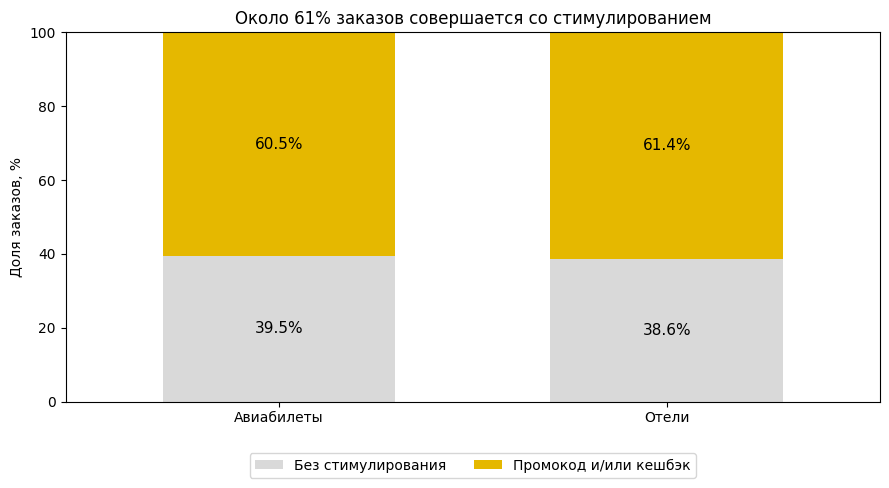

In [ ]:
#Строим график стимулирования
stimulus_plot = (
    stimulus_share
    .pivot(
        index='order_type_cd',
        columns='incentive_label',
        values='share_pct'
    )
    [['Без стимулирования', 'Промокод и/или кешбэк']]
)

stimulus_plot.index = stimulus_plot.index.map({
    'AIR': 'Авиабилеты',
    'HOT': 'Отели'
})

ax = stimulus_plot.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5),
    color=['#D9D9D9', '#E5B800'],
    width=0.6
)

for container in ax.containers:
    labels = [
        f'{value:.1f}%' if value >= 5 else ''
        for value in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=11
    )

plt.title('Около 61% заказов совершается со стимулированием')
plt.xlabel('')
plt.ylabel('Доля заказов, %')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
plt.tight_layout()

plt.savefig(
    '../images/stimulus_share.png,
    dpi=200,
    bbox_inches='tight'
)

plt.show()

In [114]:
#Проверяем связь стимулирования со статусом SUC. Поскольку у отелей есть пропуски статуса, долю SUC считаем только среди заказов с известным статусом.
success_summary = (
    orders
    .groupby(['order_type_cd', 'has_incentive'])
    .agg(
        orders_count=('order_rk', 'count'),
        known_status_count=(
            'order_status_cd',
            lambda x: x.notna().sum()
        ),
        missing_status_count=(
            'order_status_cd',
            lambda x: x.isna().sum()
        ),
        suc_count=(
            'order_status_cd',
            lambda x: (x == 'SUC').sum()
        )
    )
    .reset_index()
)

success_summary['suc_share_known_pct'] = (
    success_summary['suc_count']
    / success_summary['known_status_count']
    * 100
).round(2)

success_summary['incentive_label'] = (
    success_summary['has_incentive']
    .map({
        False: 'Без стимулирования',
        True: 'Со стимулированием'
    })
)

display(success_summary)

,order_type_cd,has_incentive,orders_count,known_status_count,missing_status_count,suc_count,suc_share_known_pct,incentive_label
0,AIR,False,242758,242758,0,230753,95.05,Без стимулирования
1,AIR,True,372579,372579,0,365403,98.07,Со стимулированием
2,HOT,False,66275,58904,7371,58699,99.65,Без стимулирования
3,HOT,True,105273,105273,0,105095,99.83,Со стимулированием


Получился полезный результат:
*    для авиабилетов доля SUC со стимулированием выше на 3,02 процентного пункта: 98,07% против 95,05%;
*    это связь, но не доказательство причинного эффекта: стимулирование могло назначаться клиентам и заказам с другими характеристиками;
*    по отелям корректное сравнение пока невозможно: все 7 371 пропуск статуса находятся в органической группе. Если исключить их, результат искусственно улучшается.

In [115]:
#Проверяем пересечение покупателей и потенциальных клиентов
hotel_clients = set(
    orders.loc[
        orders['order_type_cd'] == 'HOT',
        'client_rk'
    ]
)

air_clients = set(
    orders.loc[
        orders['order_type_cd'] == 'AIR',
        'client_rk'
    ]
)

prospect_clients = set(prospects['client_rk'])

print('Уникальных покупателей отелей:', len(hotel_clients))
print('Уникальных покупателей авиабилетов:', len(air_clients))
print('Уникальных потенциальных клиентов:', len(prospect_clients))

print(
    'Пересечение потенциальных клиентов с покупателями отелей:',
    len(prospect_clients & hotel_clients)
)

print(
    'Пересечение потенциальных клиентов с покупателями авиабилетов:',
    len(prospect_clients & air_clients)
)

Уникальных покупателей отелей: 46966
Уникальных покупателей авиабилетов: 86897
Уникальных потенциальных клиентов: 49053
Пересечение потенциальных клиентов с покупателями отелей: 0
Пересечение потенциальных клиентов с покупателями авиабилетов: 0


In [116]:
#Создаём клиентскую таблицу для сравнения. Для покупателей оставим по одной строке на клиента, иначе клиенты с несколькими заказами получат слишком большой вес.
hotel_client_profile = (
    orders.loc[
        orders['order_type_cd'] == 'HOT'
    ]
    .sort_values('created_dttm')
    .drop_duplicates(
        subset='client_rk',
        keep='last'
    )
    .copy()
)

hotel_client_profile['client_segment'] = 'Покупатели отелей'

prospect_client_profile = (
    prospects
    .drop_duplicates(      #обеспечивает гранулярность: одна строка = один клиент
        subset='client_rk',
        keep='last'
    )
    .copy()
)

prospect_client_profile['client_segment'] = 'Потенциальные клиенты'

client_comparison = pd.concat(
    [
        hotel_client_profile,
        prospect_client_profile
    ],
    ignore_index=True
)

print('Покупателей отелей в клиентской таблице:', len(hotel_client_profile))
print('Потенциальных клиентов:', len(prospect_client_profile))
print('Всего строк:', len(client_comparison))
print(
    'Уникальных клиентов:',
    client_comparison['client_rk'].nunique()
)

/tmp/ipykernel_1419/10106259.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  client_comparison = pd.concat(


Покупателей отелей в клиентской таблице: 46966
Потенциальных клиентов: 49053
Всего строк: 96019
Уникальных клиентов: 96019


In [117]:
#Сравниваем числовые характеристики. Используем медианы, потому что доход и баланс обычно имеют выбросы. Такая оценка лучше описывает типичного клиента, чем среднее.
numeric_client_profile = (
    client_comparison
    .groupby('client_segment')
    .agg(
        clients_count=('client_rk', 'nunique'),
        median_age=('age', 'median'),
        median_monthly_income=(
            'monthly_income_amt',
            'median'
        ),
        median_balance=(
            'month_beginning_balance_rub',
            'median'
        ),
        median_children=(
            'children_cnt',
            'median'
        )
    )
    .round(2)
)

display(numeric_client_profile)

,clients_count,median_age,median_monthly_income,median_balance,median_children
client_segment,,,,,
Покупатели отелей,46966,36.0,100500.0,5261.0,0.0
Потенциальные клиенты,49053,34.0,53600.0,NaN,0.0


Предварительно покупатели отелей старше на 2 года и имеют почти вдвое больший медианный доход. Но вывод о доходе можно делать только после проверки заполненности.

median_balance = NaN у потенциальных клиентов ожидаем: в словаре это баланс на начало месяца совершения покупки, а покупки у этой группы нет.

In [118]:
#Проверяем заполненность характеристик. Таблица покажет процент клиентов, для которых заполнено каждое поле. Если доход заполнен у групп сильно по-разному, разницу медиан нужно интерпретировать осторожно. Баланс потенциальных клиентов исключим из сравнительного анализа.
profile_columns = [
    'age',
    'monthly_income_amt',
    'month_beginning_balance_rub',
    'children_cnt'
]

profile_completeness = (
    client_comparison
    .groupby('client_segment')[profile_columns]
    .apply(lambda group: group.notna().mean() * 100)
    .round(2)
)

profile_completeness.columns = [
    'Возраст, %',
    'Доход, %',
    'Баланс, %',
    'Количество детей, %'
]

display(profile_completeness)

,"Возраст, %","Доход, %","Баланс, %","Количество детей, %"
client_segment,,,,
Покупатели отелей,100.0,81.85,99.2,91.24
Потенциальные клиенты,100.0,75.43,0.0,77.73


Заполненность достаточная для сравнения:

*    возраст заполнен у 100% обеих групп;
*    доход — у 81,85% покупателей и 75,43% потенциальных клиентов;
*    разницу доходов можно использовать, но с оговоркой о пропусках;
*    баланс исключаем: у потенциальных клиентов он отсутствует по смыслу поля;
*    количество детей заполнено не полностью, поэтому пока не берём его в основной вывод.

In [119]:
#Проверяем возраст на аномалии. Минимум и максимум помогут обнаружить невозможные значения, а 1-й и 99-й процентили покажут нормальные границы основной массы клиентов.
age_quality = (
    client_comparison
    .groupby('client_segment')['age']
    .agg(
        min_age='min',
        percentile_1=lambda x: x.quantile(0.01),
        median_age='median',
        percentile_99=lambda x: x.quantile(0.99),
        max_age='max'
    )
    .round(1)
)

display(age_quality)

,min_age,percentile_1,median_age,percentile_99,max_age
client_segment,,,,,
Покупатели отелей,14.0,21.0,36.0,63.0,98.0
Потенциальные клиенты,14.0,16.0,34.0,67.0,92.0


Возраст 14 лет выглядит необычно, но не является единичной ошибкой: у 1% потенциальных клиентов возраст не превышает 16 лет. Возможно, в потенциальную аудиторию попали несовершеннолетние клиенты, которые менее склонны самостоятельно бронировать отели. Это может стать продуктовым выводом, но нужно посмотреть всю структуру.

In [120]:
#Формируем возрастные группы. Таблица покажет долю каждого возрастного сегмента среди покупателей отелей и потенциальных клиентов.
age_bins = [0, 17, 24, 34, 44, 54, 64, float('inf')]

age_labels = [
    'До 17',
    '18–24',
    '25–34',
    '35–44',
    '45–54',
    '55–64',
    '65+'
]

client_comparison['age_group'] = pd.cut(
    client_comparison['age'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

age_group_summary = (
    client_comparison
    .groupby(
        ['client_segment', 'age_group'],
        observed=True
    )
    .size()
    .reset_index(name='clients_count')
)

age_group_summary['share_pct'] = (
    age_group_summary['clients_count']
    / age_group_summary.groupby('client_segment')['clients_count'].transform('sum')
    * 100
).round(2)

display(age_group_summary)

,client_segment,age_group,clients_count,share_pct
0,Покупатели отелей,До 17,40,0.09
1,Покупатели отелей,18–24,2290,4.88
2,Покупатели отелей,25–34,16746,35.66
3,Покупатели отелей,35–44,19366,41.23
4,Покупатели отелей,45–54,6492,13.82
5,Покупатели отелей,55–64,1664,3.54
6,Покупатели отелей,65+,368,0.78
7,Потенциальные клиенты,До 17,1217,2.48
8,Потенциальные клиенты,18–24,9645,19.66
9,Потенциальные клиенты,25–34,14202,28.95


## Различие выраженное

*    ядро покупателей отелей — клиенты 35–44 лет: 41,23% против 28,98% среди потенциальных клиентов;
*    среди потенциальных клиентов сильно больше аудитория 18–24 лет: 19,66% против 4,88% среди покупателей;
*    это указывает на потенциальный резерв роста в молодом сегменте, но сначала нужно понять барьеры и протестировать подходящее предложение.

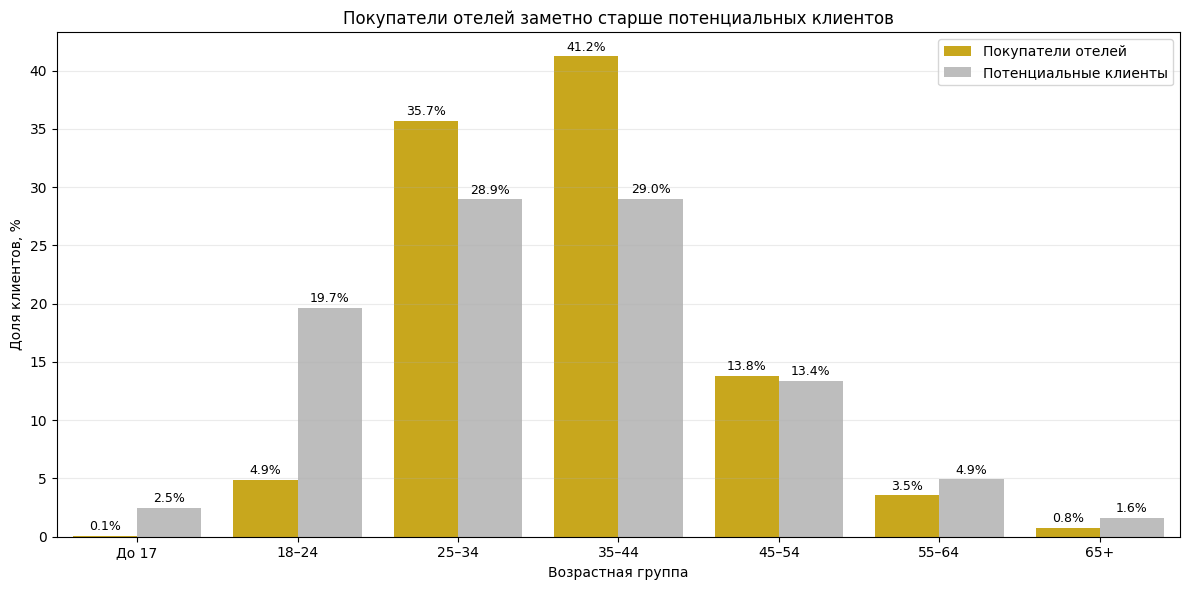

In [ ]:
#Строим график возрастных сегментов
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=age_group_summary,
    x='age_group',
    y='share_pct',
    hue='client_segment',
    palette={
        'Покупатели отелей': '#E5B800',
        'Потенциальные клиенты': '#BDBDBD'
    }
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=2,
        fontsize=9
    )

plt.title('Покупатели отелей заметно старше потенциальных клиентов')
plt.xlabel('Возрастная группа')
plt.ylabel('Доля клиентов, %')
plt.legend(title='')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()

plt.savefig(
    '../images/age_segments.png,
    dpi=200,
    bbox_inches='tight'
)

plt.show()

In [122]:
#Проверяем распределение дохода. До построения графика проверяем выбросы: очень большие доходы могут растянуть шкалу и сделать основную часть распределения неразличимой.
income_quality = (
    client_comparison
    .groupby('client_segment')['monthly_income_amt']
    .agg(
        filled_values='count',
        min_income='min',
        percentile_1=lambda x: x.quantile(0.01),
        median_income='median',
        percentile_95=lambda x: x.quantile(0.95),
        percentile_99=lambda x: x.quantile(0.99),
        max_income='max'
    )
    .round(2)
)

display(income_quality)

,filled_values,min_income,percentile_1,median_income,percentile_95,percentile_99,max_income
client_segment,,,,,,,
Покупатели отелей,38444,0.0,0.0,100500.0,435500.0,784762.98,16750000.0
Потенциальные клиенты,37000,0.0,0.0,53600.0,201000.0,469000.00,67000000.0


Доход имеет экстремальные выбросы до 16,75 и 67 млн ₽, поэтому среднее и обычную гистограмму использовать нельзя. Также как минимум 1% клиентов имеют доход 0 — это может означать реальное отсутствие дохода или техническое значение.

In [123]:
#Проверяем нулевые доходы. Если нулевых значений мало, для сравнения доходных групп исключим их как неинформативные, но не будем удалять строки из исходного датасета.
income_zero_check = (
    client_comparison
    .groupby('client_segment')
    .agg(
        clients_total=('client_rk', 'count'),
        income_filled=(
            'monthly_income_amt',
            lambda x: x.notna().sum()
        ),
        income_zero=(
            'monthly_income_amt',
            lambda x: (x == 0).sum()
        ),
        income_positive=(
            'monthly_income_amt',
            lambda x: (x > 0).sum()
        ),
        income_negative=(
            'monthly_income_amt',
            lambda x: (x < 0).sum()
        )
    )
)

income_zero_check['zero_share_among_filled_pct'] = (
    income_zero_check['income_zero']
    / income_zero_check['income_filled']
    * 100
).round(2)

display(income_zero_check)

,clients_total,income_filled,income_zero,income_positive,income_negative,zero_share_among_filled_pct
client_segment,,,,,,
Покупатели отелей,46966,38444,392,38052,0,1.02
Потенциальные клиенты,49053,37000,433,36567,0,1.17


Нулевых доходов около 1% в обеих группах, поэтому они практически не влияют на сравнение. Для сегментации используем только положительные заполненные значения, а пропуски и нули оставим в исходных данных без изменения.

In [124]:
#Формируем доходные сегменты. Доли будут рассчитаны только среди клиентов с известным положительным доходом.
income_clients = client_comparison.loc[
    client_comparison['monthly_income_amt'] > 0
].copy()

income_bins = [
    0,
    50_000,
    100_000,
    200_000,
    400_000,
    float('inf')
]

income_labels = [
    'До 50 тыс.',
    '50–100 тыс.',
    '100–200 тыс.',
    '200–400 тыс.',
    'Более 400 тыс.'
]

income_clients['income_group'] = pd.cut(
    income_clients['monthly_income_amt'],
    bins=income_bins,
    labels=income_labels,
    include_lowest=True
)

income_group_summary = (
    income_clients
    .groupby(
        ['client_segment', 'income_group'],
        observed=True
    )
    .size()
    .reset_index(name='clients_count')
)

income_group_summary['share_pct'] = (
    income_group_summary['clients_count']
    / income_group_summary.groupby('client_segment')['clients_count'].transform('sum')
    * 100
).round(2)

display(income_group_summary)

,client_segment,income_group,clients_count,share_pct
0,Покупатели отелей,До 50 тыс.,7168,18.84
1,Покупатели отелей,50–100 тыс.,10608,27.88
2,Покупатели отелей,100–200 тыс.,11511,30.25
3,Покупатели отелей,200–400 тыс.,6404,16.83
4,Покупатели отелей,Более 400 тыс.,2361,6.20
5,Потенциальные клиенты,До 50 тыс.,16572,45.32
6,Потенциальные клиенты,50–100 тыс.,11865,32.45
7,Потенциальные клиенты,100–200 тыс.,5994,16.39
8,Потенциальные клиенты,200–400 тыс.,1639,4.48
9,Потенциальные клиенты,Более 400 тыс.,497,1.36


## Различие выраженное:

*    среди покупателей отелей 53,3% имеют доход выше 100 тыс. ₽;
*    среди потенциальных клиентов таких только 22,2%;
*    доход до 50 тыс. ₽ имеют 45,3% потенциальных клиентов и только 18,8% покупателей.

Доход связан с вероятностью покупки, но не доказывает причинность.

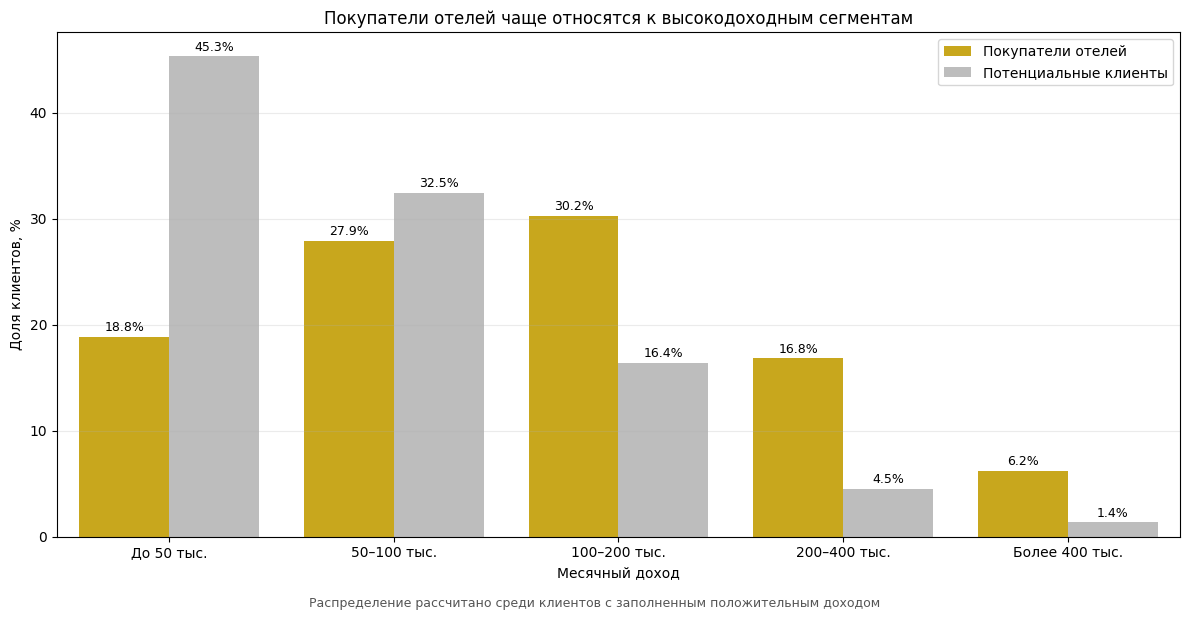

In [ ]:
#Строим график доходных сегментов
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=income_group_summary,
    x='income_group',
    y='share_pct',
    hue='client_segment',
    palette={
        'Покупатели отелей': '#E5B800',
        'Потенциальные клиенты': '#BDBDBD'
    }
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=2,
        fontsize=9
    )

plt.title('Покупатели отелей чаще относятся к высокодоходным сегментам')
plt.xlabel('Месячный доход')
plt.ylabel('Доля клиентов, %')
plt.legend(title='')
plt.grid(axis='y', alpha=0.25)

plt.figtext(
    0.5,
    -0.02,
    'Распределение рассчитано среди клиентов с заполненным положительным доходом',
    ha='center',
    fontsize=9,
    color='#555555'
)

plt.tight_layout()

plt.savefig(
    '../images/income_segments.png,
    dpi=200,
    bbox_inches='tight'
)

plt.show()

## Основные выводы EDA

### 1. Структура и динамика заказов

В датасете представлено 786 885 заказов и 49 053 потенциальных клиента,
которые не совершали покупок в сервисе. На авиабилеты приходится 615 337
заказов, на отели — 171 548.

С января по июль 2024 года количество заказов авиабилетов выросло
с 54,3 до 68,2 тыс., после чего снизилось до 61,4 тыс. в октябре.
Количество заказов отелей выросло с 11,6 тыс. в январе до 19 тыс.
в сентябре. Ноябрь исключён из сравнения, поскольку данные представлены
только по 7 ноября.

Медианная стоимость авиазаказа составляет 10 189 ₽, заказа отеля —
5 632 ₽. Средние значения существенно выше медиан из-за наличия
дорогих заказов, поэтому для описания типичного чека использовалась медиана.

### 2. Стимулирование заказов

60,55% заказов авиабилетов и 61,37% заказов отелей совершены
с промокодом и/или начислением кешбэка. Основным способом стимулирования
является кешбэк, а доля заказов с промокодом не превышает 1%.

Среди авиазаказов доля статуса SUC составляет 98,07% в стимулированной группе и 95,05% в органической. Интерпретация SUC как успешного заказа является предположением из-за отсутствия расшифровки кодов.

Для отелей аналогичное сравнение ограничено качеством данных:
все 7 371 заказа без статуса относятся к органической группе.

### 3. Портрет покупателей отелей

Покупатели отелей отличаются от потенциальных клиентов по возрасту
и доходу. 76,9% покупателей входят в возрастные группы 25–44 лет,
среди потенциальных клиентов эта доля составляет 57,9%.

Аудитория 18–24 лет составляет 19,7% потенциальных клиентов,
но только 4,9% покупателей отелей. Это указывает на возможный
нереализованный потенциал молодого сегмента.

Среди клиентов с известным положительным доходом 53,3% покупателей
отелей имеют месячный доход выше 100 тыс. ₽. Среди потенциальных
клиентов таких 22,2%. При этом доход до 50 тыс. ₽ имеют 45,3%
потенциальных клиентов и 18,8% покупателей.

Наблюдаемые различия являются ассоциациями и не позволяют без
дополнительного эксперимента сделать вывод о причинном влиянии
возраста, дохода или стимулирования на покупку.

Указанные величины ожидаемого изменения являются заранее заданными
критериями успешности экспериментов, а не прогнозами, полученными
из текущего датасета.

## Продуктовые гипотезы

### Гипотеза 1. Предложение для молодых клиентов

Если потенциальным клиентам 18–24 лет показать персональное предложение
на первое бронирование отеля с повышенным кешбэком, то конверсия в первый
заказ отеля увеличится минимум на 10% относительно контрольной группы
за 4 недели, поскольку этот возрастной сегмент заметно недопредставлен
среди покупателей: 4,9% против 19,7% среди потенциальных клиентов.

**Целевая аудитория:** потенциальные клиенты 18–24 лет без заказов отелей.  
**Изменение:** персональный баннер в приложении и повышенный кешбэк
на первое бронирование.  
**Основная метрика:** конверсия в первый заказ отеля.  
**Дополнительные метрики:** стоимость привлечённого покупателя,
медианный чек, доля отмен и повторное бронирование.

### Гипотеза 2. Подборка доступных отелей

Если клиентам с доходом до 100 тыс. ₽ показывать персональную подборку
доступных отелей с сортировкой по итоговой цене и размеру кешбэка,
то конверсия из просмотра подборки в бронирование увеличится минимум
на 7% относительно контрольной группы за 4 недели, поскольку этот
доходный сегмент составляет 77,8% потенциальной аудитории, но только
46,7% покупателей отелей.

**Целевая аудитория:** потенциальные клиенты с доходом до 100 тыс. ₽.  
**Изменение:** блок «Выгодные варианты для вашей поездки» с итоговой
ценой после кешбэка и фильтром по бюджету.  
**Основная метрика:** конверсия из просмотра подборки в бронирование.  
**Дополнительные метрики:** CTR подборки, медианный чек, маржинальность
и доля повторных заказов.

### Гипотеза 3. Персонализация стимулирования

Если персонализировать размер кешбэка на основе вероятности
инкрементальной покупки, то количество инкрементальных заказов
на 1 000 ₽ номинального объёма стимулирования увеличится минимум
на 10% за 6 недель относительно текущей механики, при этом общая
конверсия снизится не более чем на 1 процентный пункт.

**Целевая аудитория:** клиенты, для которых предложение потенциально
изменяет решение о покупке.  
**Изменение:** тестирование разных уровней кешбэка и контрольной группы
без дополнительного стимулирования.  
**Основная метрика:** инкрементальные заказы на 1 000 ₽ расходов
на кешбэк.  
**Дополнительные метрики:** конверсия, стоимость стимулирования,
медианный чек и доля статуса SUC после подтверждения его расшифровки.

In [126]:
#Оцениваем объём стимулирования.

#Этот расчёт покажет:

#-сколько заказов было стимулировано;
#-общую сумму начисленного кешбэка;
#-сумму скидок по промокодам;
#-типичный размер стимулирования.

incentive_economics = (
    orders
    .groupby('order_type_cd')
    .agg(
        orders_count=('order_rk', 'count'),
        stimulated_orders=(
            'has_incentive',
            'sum'
        ),
        total_cashback_rub=(
            'loyalty_accrual_rub_amt',
            'sum'
        ),
        total_promo_discount_rub=(
            'promo_code_discount_amt',
            'sum'
        ),
        median_positive_cashback_rub=(
            'loyalty_accrual_rub_amt',
            lambda x: x[x > 0].median()
        ),
        median_positive_promo_rub=(
            'promo_code_discount_amt',
            lambda x: x[x > 0].median()
        )
    )
    .round(2)
)

incentive_economics['total_incentive_rub'] = (
    incentive_economics['total_cashback_rub']
    + incentive_economics['total_promo_discount_rub']
)

display(incentive_economics)

,orders_count,stimulated_orders,total_cashback_rub,total_promo_discount_rub,median_positive_cashback_rub,median_positive_promo_rub,total_incentive_rub
order_type_cd,,,,,,,
AIR,615337,372579,265906340.0,2686693.0,377.0,335.0,268593033.0
HOT,171548,105273,40272337.0,669330.0,95.0,1340.0,40941667.0


## Выбор наиболее перспективной гипотезы

Наиболее перспективной выбрана гипотеза персонализации стимулирования.

В исследуемом периоде 477 852 заказа, или около 61% всех заказов,
совершены с промокодом и/или кешбэком. Суммарный номинальный объём
начисленного кешбэка и скидок по промокодам составляет около
309,5 млн ₽. При этом основная часть стимулирования приходится
на кешбэк.

Наблюдательные данные не позволяют определить, какие стимулированные
заказы не состоялись бы без предложения. Часть клиентов могла совершить
покупку органически, поэтому одинаковое стимулирование широкой аудитории
может приводить к избыточным начислениям.

### Почему гипотеза перспективна

1. **Большой масштаб.** Стимулирование применяется примерно к 61%
   заказов обоих продуктов, поэтому даже небольшое повышение эффективности
   может оказать заметное влияние.

2. **Прямой бизнес-эффект.** Гипотеза направлена не только на рост заказов,
   но и на снижение объёма неинкрементального стимулирования.

3. **Измеримость.** Эффект можно проверить с помощью контролируемого
   эксперимента, сравнив текущую механику и персонализированное назначение
   кешбэка.

4. **Применимость к обоим продуктам.** Подход можно использовать и для
   авиабилетов, и для отелей.

### Предлагаемая проверка

Клиентов, подходящих для стимулирования, необходимо случайным образом
разделить на группы:

- контрольная группа — текущая механика кешбэка;
- тестовая группа — персонализированный размер кешбэка на основе
  вероятности инкрементальной покупки.

**Основная метрика:** количество инкрементальных заказов на 1 000 ₽
номинального объёма стимулирования.

**Критерий успешности:** рост основной метрики минимум на 10%
относительно текущей механики за 6 недель при снижении общей конверсии не более чем на 1 процентный пункт.

**Дополнительные метрики:** конверсия в заказ, номинальный объём
стимулирования на заказ, медианный чек и повторные покупки.

**Защитные метрики:** общее количество заказов, валовая прибыль,
доля отменённых заказов и количество обращений клиентов.

Важно: номинальный объём начислений не равен фактическим расходам банка.
Для расчёта финансового эффекта потребуются данные о маржинальности,
себестоимости кешбэка и органической вероятности покупки.

In [127]:
#Проверяем данные для расчёта доли рынка
market_numerator_check = (
    orders
    .groupby('order_type_cd')
    .agg(
        created_orders=('order_rk', 'count'),
        item_count_filled=(
            'order_item_cnt',
            lambda x: x.notna().sum()
        ),
        total_items=(
            'order_item_cnt',
            'sum'
        ),
        total_order_value_rub=(
            'nominal_price_rub_amt',
            'sum'
        )
    )
    .round(2)
)

display(market_numerator_check)

print('Основные страны в заказах отелей:')

display(
    orders.loc[
        orders['order_type_cd'] == 'HOT',
        'hotel_country'
    ]
    .value_counts(dropna=False)
    .head(15)
    .reset_index(name='orders_count')
)

,created_orders,item_count_filled,total_items,total_order_value_rub
order_type_cd,,,,
AIR,615337,615337,861419.0,9.890226e+09
HOT,171548,0,0.0,2.053197e+09


Основные страны в заказах отелей:


,hotel_country,orders_count
0,Россия,120729
1,NaN,9300
2,Турция,7511
3,Таиланд,5611
4,ОАЭ,3903
5,Италия,2002
6,Китай,1912
7,Япония,1787
8,Грузия,1519
9,Казахстан,1322


Для авиабилетов поле заполнено полностью: 615 337 заказов содержат 861 419 позиций. Это можно использовать как приближение количества проданных билетов, но не как точное число пассажиров.

Для отелей order_item_cnt не используется, поэтому считаем количество ночей по датам заезда и выезда. В России находится 120 729 бронирований — около 70% всех заказов отелей.

In [128]:
#Рассчитываем ночёвки в российских отелях. Сначала проверяем качество длительности проживания. Только после этого будем суммировать ночи и считать долю рынка.
hotel_russia = orders.loc[
    (orders['order_type_cd'] == 'HOT')
    & (orders['hotel_country'] == 'Россия')
].copy()

hotel_russia['book_start_dttm'] = pd.to_datetime(
    hotel_russia['book_start_dttm'],
    errors='coerce'
)

hotel_russia['book_end_dttm'] = pd.to_datetime(
    hotel_russia['book_end_dttm'],
    errors='coerce'
)

hotel_russia['stay_nights'] = (
    hotel_russia['book_end_dttm']
    - hotel_russia['book_start_dttm']
).dt.days

nights_quality = pd.DataFrame({
    'Показатель': [
        'Бронирований в России',
        'Пропусков количества ночей',
        'Нулевых ночей',
        'Отрицательных ночей',
        'Медиана ночей',
        '95-й процентиль',
        '99-й процентиль',
        'Максимум ночей'
    ],
    'Значение': [
        len(hotel_russia),
        hotel_russia['stay_nights'].isna().sum(),
        (hotel_russia['stay_nights'] == 0).sum(),
        (hotel_russia['stay_nights'] < 0).sum(),
        hotel_russia['stay_nights'].median(),
        hotel_russia['stay_nights'].quantile(0.95),
        hotel_russia['stay_nights'].quantile(0.99),
        hotel_russia['stay_nights'].max()
    ]
})

display(nights_quality)

,Показатель,Значение
0,Бронирований в России,120729.0
1,Пропусков количества ночей,0.0
2,Нулевых ночей,0.0
3,Отрицательных ночей,0.0
4,Медиана ночей,1.0
5,95-й процентиль,5.0
6,99-й процентиль,8.0
7,Максимум ночей,30.0


Длительность проживания выглядит корректно: пропусков и невозможных значений нет, медиана — одна ночь, максимум — 30 ночей.

Из-за отсутствия расшифровки статусов посчитаем диапазон доли:

*    нижняя граница — только заказы со статусом SUC;
*    верхняя — все созданные заказы

In [129]:
#Оцениваем диапазон доли рынка
period_start = orders['created_dttm'].min().normalize()
period_end = orders['created_dttm'].max().normalize()

covered_days = (period_end - period_start).days + 1
days_in_2024 = 366
annualization_factor = days_in_2024 / covered_days

air_all_items = orders.loc[
    orders['order_type_cd'] == 'AIR',
    'order_item_cnt'
].sum()

air_suc_items = orders.loc[
    (orders['order_type_cd'] == 'AIR')
    & (orders['order_status_cd'] == 'SUC'),
    'order_item_cnt'
].sum()

hotel_all_nights = hotel_russia['stay_nights'].sum()

hotel_suc_nights = hotel_russia.loc[
    hotel_russia['order_status_cd'] == 'SUC',
    'stay_nights'
].sum()

air_market_2024 = 111_700_000
hotel_market_2024 = 242_000_000

market_share_estimate = pd.DataFrame({
    'Продукт': [
        'Авиабилеты',
        'Отели в России'
    ],
    'Нижняя оценка объёма за период': [
        air_suc_items,
        hotel_suc_nights
    ],
    'Верхняя оценка объёма за период': [
        air_all_items,
        hotel_all_nights
    ],
    'Объём индустрии за 2024 год': [
        air_market_2024,
        hotel_market_2024
    ]
})

market_share_estimate['Нижняя доля, %'] = (
    market_share_estimate['Нижняя оценка объёма за период']
    * annualization_factor
    / market_share_estimate['Объём индустрии за 2024 год']
    * 100
).round(2)

market_share_estimate['Верхняя доля, %'] = (
    market_share_estimate['Верхняя оценка объёма за период']
    * annualization_factor
    / market_share_estimate['Объём индустрии за 2024 год']
    * 100
).round(2)

print('Начало периода:', period_start.date())
print('Конец периода:', period_end.date())
print('Количество календарных дней:', covered_days)
print('Коэффициент приведения к полному году:', round(annualization_factor, 3))

display(market_share_estimate)

Начало периода: 2024-01-01
Конец периода: 2024-11-07
Количество календарных дней: 312
Коэффициент приведения к полному году: 1.173


,Продукт,Нижняя оценка объёма за период,Верхняя оценка объёма за период,Объём индустрии за 2024 год,"Нижняя доля, %","Верхняя доля, %"
0,Авиабилеты,832515.0,861419.0,111700000,0.87,0.90
1,Отели в России,227804.0,228322.0,242000000,0.11,0.11


## Оценка доли Т-Банка в индустрии

### Авиабилеты

В датасете за период с 1 января по 7 ноября 2024 года содержится
861 419 позиций в заказах авиабилетов. Если использовать только заказы
со статусом SUC, значение составляет 832 515 позиций.

Показатели приведены к полному 2024 году с коэффициентом 366 / 312.
В качестве объёма индустрии использован пассажиропоток российских
авиакомпаний — 111,7 млн пассажиров за 2024 год.

Оценочная доля сервиса составляет **0,87–0,90%**.

Источник: [Министерство транспорта РФ — пассажиропоток российских
авиакомпаний в 2024 году](https://mintrans.gov.ru/press-center/news/11689).

### Отели

В датасете рассчитано 228 322 ночи по бронированиям российских отелей.
При использовании только заказов со статусом SUC получается
227 804 ночи. После приведения к полному году показатели сопоставлены
с объёмом гостиничного рынка России — 242 млн ночёвок в 2024 году.

Оценочная доля сервиса составляет около **0,11%**.

Источник: [BusinessStat — анализ рынка гостиничных услуг России](https://businesstat.ru/images/demo/hotels_russia_demo_businesstat.pdf).

### Ограничения оценки

Полученные значения не являются официальной рыночной долей Т-Банка
и показывают только примерный порядок величины.

- Количество позиций в авиазаказе может не совпадать с количеством
  уникальных пассажиров.
- Неизвестно, билеты каких авиакомпаний представлены в датасете,
  тогда как внешний показатель относится к российским авиакомпаниям.
- Для отелей отсутствует количество забронированных номеров, поэтому
  одна ночь проживания принята за одну номеро-ночь.
- Внешний показатель включает весь гостиничный рынок, а не только
  онлайн-бронирования.
- Данные Т-Банка представлены за неполный год. Простая экстраполяция
  предполагает равномерность спроса и не полностью учитывает сезонность.
- Расшифровка статусов отсутствует, поэтому представлен диапазон:
  только SUC и все созданные заказы.

Для более точной оценки необходимы данные об уникальных билетах,
количестве забронированных номеров, географии перевозчиков и сопоставимый
объём рынка за тот же период и канал продаж.

## Использование AI

При выполнении тестового задания использовался ChatGPT.

AI применялся для:

- составления последовательного плана разведочного анализа;
- объяснения синтаксиса Python и методов pandas;
- диагностики ошибки чтения CSV и определения корректных параметров
  `sep=';'` и `decimal=','`;
- обсуждения способов проверки качества данных и гранулярности;
- помощи в выборе подходящих визуализаций;
- структурирования продуктовых гипотез и плана их экспериментальной проверки;
- поиска открытых источников для приблизительной оценки доли рынка;
- редактирования формулировок выводов и ограничений исследования.

Все расчёты выполнялись на полном датасете в Google Colab. Результаты
каждого этапа проверялись и интерпретировались автором работы. AI
не использовался как источник фактических значений показателей:
числовые результаты получены непосредственно из датасета, а внешние
данные сопровождаются ссылками на источники.

Использование AI помогло быстрее разобраться с незнакомыми функциями
Python, систематизировать анализ и уделить больше внимания интерпретации
результатов. Ограничения данных, допущения и финальные выводы были
проверены автором отдельно.